# Speed Classification Using Smartphone Sensors

In this project, we aim to classify human locomotion into four speed categories—**slow walk (~2 mph), brisk walk (~3.5–4 mph), jog (~5–5.5 mph), and run (~7+ mph)**—using smartphone sensor data.  



## Sliding Window Segmentation

To align with the project specification, we explored segmenting raw sensor recordings into fixed-length time windows.  
In particular, we defined a sliding window procedure that divides each trial into **5-second windows**, corresponding to approximately 250 samples at a 50 Hz sampling rate.

Each window can be treated as an individual instance, allowing multiple labeled samples to be extracted from a single treadmill trial.


In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Paths
base_path = "../data"

speed_map = {
    "slow_walk": 2,    # mph
    "fast_walk": 4,
    "jogging": 5.5,
    "running": 7
}

# --- Windowing function (5-second sliding windows) ---
def create_windows(df, window_size=5.0, sampling_rate=50):
    """
    Convert raw accelerometer CSV into multiple window samples.
    Each window is 5 seconds (5 * 50 = 250 samples).
    """

    window_len = int(window_size * sampling_rate)
    rows = []

    for start in range(0, len(df) - window_len, window_len):
        window = df.iloc[start : start + window_len].copy()
        rows.append(window)

    return rows




## Feature Engineering

For each trial, we extract statistical features from both accelerometer and gyroscope signals.  
These include the mean and standard deviation of the x, y, and z axes, as well as the magnitude of each sensor signal.

Acceleration and gyroscope magnitudes are computed as:

\[
\sqrt{x^2 + y^2 + z^2}
\]

This feature representation summarizes overall motion intensity and variability within each trial.


In [2]:
def compute_features(win):
    win["mag"] = np.sqrt(win.x**2 + win.y**2 + win.z**2)

    return {
        "x_mean": win.x.mean(),
        "y_mean": win.y.mean(),
        "z_mean": win.z.mean(),
        "mag_mean": win.mag.mean(),

        "x_std": win.x.std(),
        "y_std": win.y.std(),
        "z_std": win.z.std(),
        "mag_std": win.mag.std(),

        "x_peak": win.x.max() - win.x.min(),
        "y_peak": win.y.max() - win.y.min(),
        "z_peak": win.z.max() - win.z.min(),
        "mag_peak": win.mag.max() - win.mag.min(),
    }


In [3]:
rows = []

for folder, speed_label in speed_map.items():
    folder_path = os.path.join(base_path, folder)
    print("Loading:", folder_path)

    for trial in os.listdir(folder_path):
        trial_path = os.path.join(folder_path, trial)
        accel_path = os.path.join(trial_path, "Accelerometer.csv")

        if not os.path.exists(accel_path):
            continue

        df = pd.read_csv(accel_path)

        # Extract 5-second windows
        windows = create_windows(df, window_size=5.0, sampling_rate=50)

        # Convert each window to a row of features
        for win in windows:
            feat = compute_features(win)
            feat["label"] = speed_label
            rows.append(feat)

dataset = pd.DataFrame(rows)
dataset.head()


Loading: ../data\slow_walk
Loading: ../data\fast_walk
Loading: ../data\jogging
Loading: ../data\running


,x_mean,y_mean,z_mean,mag_mean,x_std,y_std,z_std,mag_std,x_peak,y_peak,z_peak,mag_peak,label
0,0.087761,0.190218,-0.033707,2.482634,1.648582,0.900489,2.025675,1.220262,7.281178,6.062861,8.919000,5.128184,2.0
1,-0.010190,0.562129,-0.469803,3.667581,2.312816,2.100482,2.472787,1.705758,11.927536,8.577289,9.739914,6.969545,2.0
2,-0.010134,0.312406,-0.259237,3.140307,2.279176,1.603314,2.175935,1.662644,14.212174,7.916066,9.928685,9.151530,2.0
3,0.021328,0.194726,-0.233708,2.989251,1.578772,1.213925,2.699542,1.541272,7.123321,6.022613,11.358993,7.036589,2.0
4,0.000072,0.079230,-0.082532,1.773156,1.188433,0.657921,1.438183,0.877515,6.272541,3.456986,10.388129,6.160557,2.0


In [4]:
# Separate features and labels
X = dataset.drop(columns=["label"])
y = dataset["label"].astype(int)

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# Save consistent features
feature_cols = X_train.columns.tolist()

# Train model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train[feature_cols], y_train)

# Predict
pred = rf.predict(X_test[feature_cols])

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

# Feature importances
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).head(10)



[[16  0  0  0]
 [ 4  9  0  0]
 [ 0  0 10  3]
 [ 0  0  5  9]]
              precision    recall  f1-score   support

           2       0.80      1.00      0.89        16
           4       1.00      0.69      0.82        13
           5       0.67      0.77      0.71        13
           7       0.75      0.64      0.69        14

    accuracy                           0.79        56
   macro avg       0.80      0.78      0.78        56
weighted avg       0.80      0.79      0.78        56



z_std       0.155288
mag_mean    0.147978
y_std       0.138508
x_mean      0.119610
y_peak      0.093220
mag_std     0.082972
z_peak      0.065233
x_std       0.064640
z_mean      0.040234
x_peak      0.037070
dtype: float64

In [5]:
top_features = importances.sort_values(ascending=False).head(5).index.tolist()

X_train_sel = X_train[top_features]
X_test_sel  = X_test[top_features]

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_sel, y_train)

print("Best Parameters:", grid.best_params_)


Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Parameters: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 50}


The best params were "max_depth" of 8, "min_samples" 5, and "n_estimators" of 50.

In [6]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test_sel)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


[[16  0  0  0]
 [ 4  9  0  0]
 [ 0  0 10  3]
 [ 0  0  3 11]]
              precision    recall  f1-score   support

           2       0.80      1.00      0.89        16
           4       1.00      0.69      0.82        13
           5       0.77      0.77      0.77        13
           7       0.79      0.79      0.79        14

    accuracy                           0.82        56
   macro avg       0.84      0.81      0.82        56
weighted avg       0.84      0.82      0.82        56



Here is our confusion matrix colorized:

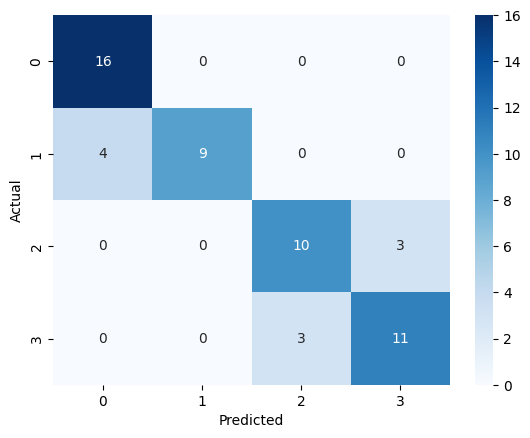

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [8]:


import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt


base_path = "../data"


speed_map = {
    "slow_walk": 0,   # ~2 mph
    "fast_walk": 1,   # ~4 mph
    "jogging":   2,   # ~5–5.5 mph
    "running":   3    # ~7+ mph
}

def accel_xyz(acc_df):
    
    num_cols = acc_df.select_dtypes(include="number").columns
    if len(num_cols) < 3:
        raise ValueError(f"Not enough numeric accel columns: {acc_df.columns}")
    acc = acc_df[num_cols[:3]].copy()
    acc.columns = ["ax", "ay", "az"]
    return acc

def gyro_xyz(gyro_df):
    
    num_cols = gyro_df.select_dtypes(include="number").columns
    if len(num_cols) < 3:
        raise ValueError(f"Not enough numeric gyro columns: {gyro_df.columns}")
    gyro = gyro_df[num_cols[:3]].copy()
    gyro.columns = ["gx", "gy", "gz"]
    return gyro

def compute_features_from_trial(acc_path, gyro_path):
    
    acc_raw = pd.read_csv(acc_path)
    gyro_raw = pd.read_csv(gyro_path)

    acc = accel_xyz(acc_raw)
    gyro = gyro_xyz(gyro_raw)

    # magnitudes
    acc["acc_mag"] = np.sqrt(acc["ax"]**2 + acc["ay"]**2 + acc["az"]**2)
    gyro["gyro_mag"] = np.sqrt(gyro["gx"]**2 + gyro["gy"]**2 + gyro["gz"]**2)

    feats = {
        # accelerometer
        "acc_x_mean": acc["ax"].mean(),  "acc_x_std": acc["ax"].std(),
        "acc_y_mean": acc["ay"].mean(),  "acc_y_std": acc["ay"].std(),
        "acc_z_mean": acc["az"].mean(),  "acc_z_std": acc["az"].std(),
        "acc_mag_mean": acc["acc_mag"].mean(),
        "acc_mag_std": acc["acc_mag"].std(),

        # gyroscope
        "gyro_x_mean": gyro["gx"].mean(), "gyro_x_std": gyro["gx"].std(),
        "gyro_y_mean": gyro["gy"].mean(), "gyro_y_std": gyro["gy"].std(),
        "gyro_z_mean": gyro["gz"].mean(), "gyro_z_std": gyro["gz"].std(),
        "gyro_mag_mean": gyro["gyro_mag"].mean(),
        "gyro_mag_std": gyro["gyro_mag"].std(),
    }
    return feats


rows = []

for speed_name, label in speed_map.items():
    speed_folder = os.path.join(base_path, speed_name)

    for trial_name in os.listdir(speed_folder):
        trial_folder = os.path.join(speed_folder, trial_name)
        if not os.path.isdir(trial_folder):
            continue

        acc_path = os.path.join(trial_folder, "Accelerometer.csv")
        gyro_path = os.path.join(trial_folder, "Gyroscope.csv")

        
        if not (os.path.exists(acc_path) and os.path.exists(gyro_path)):
            continue

        feats = compute_features_from_trial(acc_path, gyro_path)
        feats["speed_name"] = speed_name
        feats["label"] = label
        feats["trial"] = trial_name
        rows.append(feats)

combined_df = pd.DataFrame(rows)
display(combined_df.head())
print("combined_df shape:", combined_df.shape)


c:\Users\natsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\natsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\natsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\natsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\natsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufun

,acc_x_mean,acc_x_std,acc_y_mean,acc_y_std,acc_z_mean,acc_z_std,acc_mag_mean,acc_mag_std,gyro_x_mean,gyro_x_std,gyro_y_mean,gyro_y_std,gyro_z_mean,gyro_z_std,gyro_mag_mean,gyro_mag_std,speed_name,label,trial
0,1.765311e+18,3.062001e+09,5.367706,3.062001,-0.209738,2.320028,2.022805e+09,7.030608e+08,1.765311e+18,3.062001e+09,5.367706,3.062001,-0.027389,0.957078,2.022805e+09,7.030608e+08,slow_walk,0,trial01
1,1.765311e+18,2.790318e+09,4.884625,2.790318,-0.075755,1.524411,2.035988e+09,7.265858e+08,1.765311e+18,2.790318e+09,4.884625,2.790318,0.042630,0.671153,2.035988e+09,7.265858e+08,slow_walk,0,trial02
2,1.765311e+18,3.079397e+09,5.383674,3.079397,-0.045611,1.547464,1.995600e+09,7.297748e+08,1.765311e+18,3.079397e+09,5.383674,3.079397,-0.006029,0.797511,1.995600e+09,7.297748e+08,slow_walk,0,trial03
3,1.765311e+18,3.195065e+09,5.610087,3.195065,-0.113750,1.743854,2.011815e+09,7.092769e+08,1.765311e+18,3.195065e+09,5.610087,3.195065,0.043280,0.927193,2.011815e+09,7.092769e+08,slow_walk,0,trial04
4,1.765311e+18,3.041929e+09,5.336266,3.041929,-0.158817,1.795071,2.030994e+09,7.135207e+08,1.765311e+18,3.041929e+09,5.336266,3.041929,0.007112,0.912967,2.030994e+09,7.135207e+08,slow_walk,0,trial05


combined_df shape: (64, 19)


Gyro feature columns: ['gyro_x_mean', 'gyro_x_std', 'gyro_y_mean', 'gyro_y_std', 'gyro_z_mean', 'gyro_z_std', 'gyro_mag_mean', 'gyro_mag_std']
Best params (Gyro-only): {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 150}
Best CV accuracy (Gyro-only): 0.8733333333333334

Classification report (Gyro-only):
              precision    recall  f1-score   support

           0      0.800     1.000     0.889         4
           1      1.000     0.750     0.857         4
           2      0.750     0.750     0.750         4
           3      0.750     0.750     0.750         4

    accuracy                          0.812        16
   macro avg      0.825     0.812     0.812        16
weighted avg      0.825     0.812     0.812        16



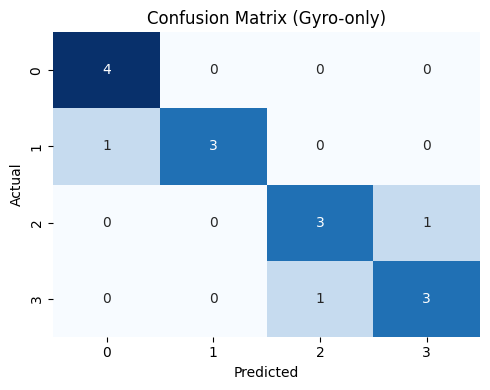

In [11]:
# ========= Gyroscope ONLY model =========

gyro_feature_cols = [c for c in combined_df.columns if c.startswith("gyro_")]
print("Gyro feature columns:", gyro_feature_cols)

X_gyro = combined_df[gyro_feature_cols]
y_gyro = combined_df["label"]


X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gyro, y_gyro,
    test_size=0.25,
    random_state=42,
    stratify=y_gyro
)


rf_base_g = RandomForestClassifier(random_state=42)

param_grid_g = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
}


grid_g = GridSearchCV(
    rf_base_g,
    param_grid=param_grid_g,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_g.fit(X_train_g, y_train_g)

print("Best params (Gyro only):", grid_g.best_params_)
print("Best CV accuracy (Gyro only):", grid_g.best_score_)


best_rf_g = RandomForestClassifier(
    **grid_g.best_params_,
    random_state=42
)

best_rf_g.fit(X_train_g, y_train_g)
y_pred_g = best_rf_g.predict(X_test_g)

print("\nClassification report (Gyro only):")
print(classification_report(y_test_g, y_pred_g, digits=3))


cm_g = confusion_matrix(y_test_g, y_pred_g)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_g, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Gyro only)")
plt.tight_layout()
plt.show()

Best params (Gyro + Accel): {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 50}
Best CV accuracy: 0.9355555555555555

Classification report (Gyro + Accel):
              precision    recall  f1-score   support

           0      0.800     1.000     0.889         4
           1      1.000     0.750     0.857         4
           2      0.800     1.000     0.889         4
           3      1.000     0.750     0.857         4

    accuracy                          0.875        16
   macro avg      0.900     0.875     0.873        16
weighted avg      0.900     0.875     0.873        16



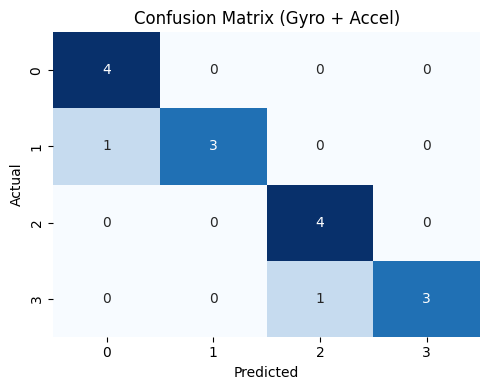

In [9]:



cols_to_drop = [c for c in ["label", "speed_name", "trial"] if c in combined_df.columns]
X = combined_df.drop(columns=cols_to_drop)
y = combined_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,       # 25% test set
    random_state=42,
    stratify=y
)


rf_base = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
}

grid = GridSearchCV(
    rf_base,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params (Gyro + Accel):", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)


best_rf = RandomForestClassifier(
    **grid.best_params_,
    random_state=42
)

best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("\nClassification report (Gyro + Accel):")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Gyro + Accel)")
plt.tight_layout()
plt.show()


gyro_x_mean      0.258421
acc_z_std        0.182722
acc_x_mean       0.174875
gyro_z_std       0.095257
acc_z_mean       0.059530
gyro_z_mean      0.053740
acc_x_std        0.042676
gyro_y_std       0.029038
acc_mag_std      0.019049
acc_y_mean       0.016467
gyro_mag_std     0.015925
gyro_y_mean      0.014209
acc_y_std        0.011922
gyro_mag_mean    0.010924
gyro_x_std       0.009840
acc_mag_mean     0.005405
dtype: float64

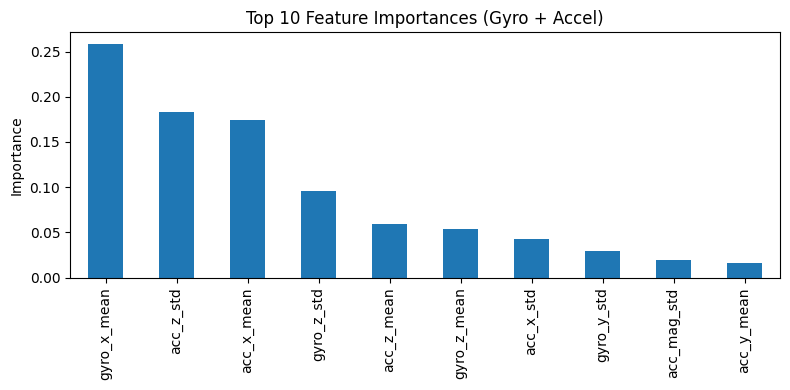

Top features: ['gyro_x_mean', 'acc_z_std', 'acc_x_mean', 'gyro_z_std', 'acc_z_mean']

Classification report (Gyro + Accel, TOP 5 features):
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         4
           1      1.000     1.000     1.000         4
           2      0.800     1.000     0.889         4
           3      1.000     0.750     0.857         4

    accuracy                          0.938        16
   macro avg      0.950     0.938     0.937        16
weighted avg      0.950     0.938     0.937        16



In [10]:



importances = pd.Series(best_rf.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

display(importances_sorted)

plt.figure(figsize=(8, 4))
importances_sorted.head(10).plot(kind="bar")
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances (Gyro + Accel)")
plt.tight_layout()
plt.show()


top_k = 5
top_features = list(importances_sorted.head(top_k).index)
print("Top features:", top_features)

X_top = X[top_features]

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

best_rf_top = RandomForestClassifier(
    **grid.best_params_,
    random_state=42
)

best_rf_top.fit(X_train_top, y_train_top)
y_pred_top = best_rf_top.predict(X_test_top)

print("\nClassification report (Gyro + Accel, TOP 5 features):")
print(classification_report(y_test_top, y_pred_top, digits=3))


c:\Users\natsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\natsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\natsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\natsu\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


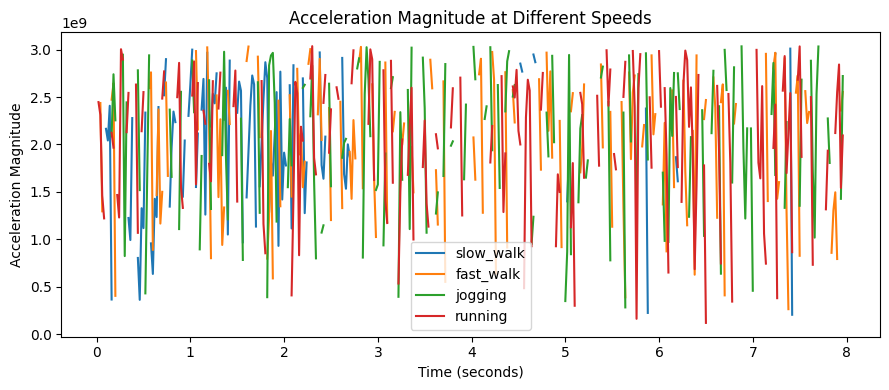

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

base_path = "../data"
sampling_rate = 50   # Hz
seconds_to_plot = 8
N = sampling_rate * seconds_to_plot

plt.figure(figsize=(9, 4))

for speed_name in ["slow_walk", "fast_walk", "jogging", "running"]:
    speed_folder = os.path.join(base_path, speed_name)
    trial_name = os.listdir(speed_folder)[0]   
    acc_path = os.path.join(speed_folder, trial_name, "Accelerometer.csv")
    
    acc_raw = pd.read_csv(acc_path)
    num_cols = acc_raw.select_dtypes(include="number").columns
    acc = acc_raw[num_cols[:3]]
    acc.columns = ["ax", "ay", "az"]

    acc_mag = np.sqrt(acc.ax**2 + acc.ay**2 + acc.az**2)

    t = np.arange(N) / sampling_rate
    plt.plot(t, acc_mag[:N], label=speed_name)

plt.xlabel("Time (seconds)")
plt.ylabel("Acceleration Magnitude")
plt.title("Acceleration Magnitude at Different Speeds")
plt.legend()
plt.tight_layout()
plt.show()


| Model                          | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|--------------------------------|----------|-----------------|-------------|----------|
| Accel-only                     | 0.82     | 0.84            | 0.81        | 0.82     |
| Gyro-only                      | 0.81     | 0.83            | 0.81        | 0.81     |
| Accel + Gyro (all features)    | 0.88     | 0.90            | 0.88        | 0.87     |
| Accel + Gyro (top 5 features)  | 0.94     | 0.95            | 0.94        | 0.94     |


We evaluated Random Forest classifiers using different sensor configurations: accelerometer-only, gyroscope-only, and a combined accelerometer and gyroscope setup.

The accelerometer-only model achieved reasonable performance (accuracy = 0.82, macro F1 = 0.82), serving as a strong baseline. The gyroscope-only model performed slightly worse(accuracy = 0.81, macro F1 = 0.81), indicating that rotational motion alone is less discriminative for speed classification than linear acceleration.

Combining accelerometer and gyroscope features improved overall performance (accuracy = 0.88, macro F1 = 0.87), suggesting that gyroscope data provides complementary information, especially in distinguishing higher-speed movements.

Using feature importance scores from the combined model, we further trained a classifier using only the top five features. This reduced-feature model achieved the best performance (accuracy = 0.94, macro F1 = 0.94), indicating that most discriminative information is concentrated in a small subset of features.

Overall, the results are consistent and expected: accelerometer features provide the strongest baseline signal, gyroscope features alone are less informative but complementary, and combining both sensors improves performance. Feature selection further improves generalization by removing noisy features.